# ViT / SegFormer 

In [1]:
!pip install -q transformers

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

import sys
sys.path.append("/kaggle/input/datasets/rarescocosila/proiect-iava")

from pathlib import Path
from model_builders import build_segformer_model
import utils
from utils import (
    DiceBCELoss,
    SEED,
    benchmark_model,
    build_experiment_result_row,
    build_optimization_profile,
    build_segmentation_dataloaders,
    collect_prediction_examples,
    count_trainable_parameters,
    create_optimizer,
    create_scaler,
    create_scheduler,
    device,
    fit_segmentation_model,
    get_protocol_splits,
    load_segmentation_checkpoint,
    plot_training_history,
    prepare_model_for_optimizations,
    quantize_model_for_inference,
    run_validation_epoch,
    seed_everything,
    summarize_protocol_splits,
    visualize_prediction_examples
)

seed_everything(SEED)
print('Device:', device)
print('Seed:', SEED)

Device: cuda
Seed: 1335


In [19]:
BASE = Path("/kaggle/input/datasets/rarescocosila/proiect-iava/dataset-iava")

utils.SEVERSTAL_ROOT = BASE / "severstal-steel-defect-detection"
utils.NEU_ROOT = BASE / "NEU-DET_data"
utils.KOLEKTOR_ROOT = BASE / "kolektor_data"

utils.TRAIN_DIR = f'{utils.SEVERSTAL_ROOT}/train_images'
utils.TRAIN_CSV = f'{utils.SEVERSTAL_ROOT}/train.csv'
utils.TEST_DIR = f'{utils.SEVERSTAL_ROOT}/test_images'

utils.build_severstal_metadata.__defaults__ = (
    utils.TRAIN_CSV,
    utils.TRAIN_DIR
)

build_severstal_metadata = utils.build_severstal_metadata

In [4]:
IMG_SIZE = 512
BATCH_SIZE = 4
EPOCHS = 12
LR = 3e-5
WEIGHT_DECAY = 1e-4
PATIENCE = 4
OPTIMIZER_NAME = 'adamw'
SCHEDULER_NAME = 'cosine'
LOSS_NAME = 'dice_bce'
NORMALIZE = 'imagenet'
REFRESH_METADATA = True
SELECTED_SOURCES = ['severstal', 'neu', 'kolektor']
QUANTIZE_CPU_BENCH = True

ACTIVE_PROFILE = build_optimization_profile(
    amp_mode='fp16',
    channels_last=True,
    compile_model=True,
    compile_mode='reduce-overhead',
    gradient_checkpointing=False,
    grad_accumulation_steps=1,
    max_grad_norm=1.0,
    ema_decay=0.999,
    persistent_workers=True,
    prefetch_factor=2,
)
ACTIVE_PROFILE

{'amp_mode': 'fp16',
 'channels_last': True,
 'compile_model': True,
 'compile_mode': 'reduce-overhead',
 'gradient_checkpointing': False,
 'grad_accumulation_steps': 1,
 'max_grad_norm': 1.0,
 'ema_decay': 0.999,
 'persistent_workers': True,
 'prefetch_factor': 2}

In [5]:
metadata, train_df, val_df, test_df = get_protocol_splits(random_state=SEED, refresh_cache=REFRESH_METADATA, cache_path="/kaggle/working/merged_metadata.csv")
train_df = train_df[train_df['source'].isin(SELECTED_SOURCES)].reset_index(drop=True)
val_df = val_df[val_df['source'].isin(SELECTED_SOURCES)].reset_index(drop=True)
test_df = test_df[test_df['source'].isin(SELECTED_SOURCES)].reset_index(drop=True)

display(summarize_protocol_splits(pd.concat([train_df, val_df, test_df], ignore_index=True)))
print('Train size:', len(train_df))
print('Val size:', len(val_df))
print('Test size:', len(test_df))

,protocol_split,source,images,defect_images,clean_images
0,train,kolektor,2097,221,1876
1,train,neu,863,863,0
2,train,severstal,10054,5333,4721
3,val,kolektor,234,25,209
4,val,neu,96,96,0
5,val,severstal,1257,666,591
6,test_final,kolektor,1004,110,894
7,test_final,neu,240,240,0
8,test_final,severstal,1257,667,590


Train size: 13014
Val size: 1587
Test size: 2501


In [6]:
train_dataset, val_dataset, train_loader, val_loader = build_segmentation_dataloaders(
    train_df=train_df,
    val_df=val_df,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=2,
    normalize=NORMALIZE,
    persistent_workers=ACTIVE_PROFILE['persistent_workers'],
    prefetch_factor=ACTIVE_PROFILE['prefetch_factor'],
)
print('Train batches:', len(train_loader))
print('Val batches:', len(val_loader))

Train batches: 3254
Val batches: 397


In [ ]:
model = build_segformer_model()
model, opt_info = prepare_model_for_optimizations(
    model,
    channels_last=ACTIVE_PROFILE['channels_last'],
    compile_model=ACTIVE_PROFILE['compile_model'],
    compile_mode=ACTIVE_PROFILE['compile_mode'],
    gradient_checkpointing=ACTIVE_PROFILE['gradient_checkpointing'],
)
criterion = DiceBCELoss() if LOSS_NAME == 'dice_bce' else None
optimizer = create_optimizer(model, name=OPTIMIZER_NAME, lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = create_scheduler(optimizer, name=SCHEDULER_NAME, epochs=EPOCHS)
scaler = create_scaler(amp_mode=ACTIVE_PROFILE['amp_mode'])
trainable_params = count_trainable_parameters(model)
print('Trainable params:', f'{trainable_params:,}')

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/15.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([4])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([4, 256, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Trainable params: 3,715,172


/kaggle/input/datasets/rarescocosila/proiect-iava/utils.py:1176: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  return GradScaler()


/kaggle/input/datasets/rarescocosila/proiect-iava/utils.py:1186: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return autocast(dtype=torch.float16)
W0427 14:34:43.180000 55 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode
/kaggle/input/datasets/rarescocosila/proiect-iava/utils.py:1186: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return autocast(dtype=torch.float16)
/kaggle/input/datasets/rarescocosila/proiect-iava/utils.py:1186: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return autocast(dtype=torch.float16)
/kaggle/input/datasets/rarescocosila/proiect-iava/utils.py:1186: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return autocast(dtype=

segformer epoch 1/12 | train_loss=0.1471 train_dice=0.8446 val_loss=0.1018 val_dice=0.8746 val_iou=0.8732


/kaggle/input/datasets/rarescocosila/proiect-iava/utils.py:1186: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return autocast(dtype=torch.float16)
/kaggle/input/datasets/rarescocosila/proiect-iava/utils.py:1186: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return autocast(dtype=torch.float16)


segformer epoch 2/12 | train_loss=0.0926 train_dice=0.8809 val_loss=0.0837 val_dice=0.8906 val_iou=0.8842
segformer epoch 3/12 | train_loss=0.0840 train_dice=0.8899 val_loss=0.0738 val_dice=0.9033 val_iou=0.8923
segformer epoch 4/12 | train_loss=0.0772 train_dice=0.8982 val_loss=0.0683 val_dice=0.9106 val_iou=0.8981
segformer epoch 5/12 | train_loss=0.0727 train_dice=0.9039 val_loss=0.0643 val_dice=0.9161 val_iou=0.9032
segformer epoch 6/12 | train_loss=0.0690 train_dice=0.9089 val_loss=0.0620 val_dice=0.9192 val_iou=0.9059
segformer epoch 7/12 | train_loss=0.0662 train_dice=0.9124 val_loss=0.0605 val_dice=0.9212 val_iou=0.9074
segformer epoch 8/12 | train_loss=0.0637 train_dice=0.9158 val_loss=0.0586 val_dice=0.9239 val_iou=0.9100
segformer epoch 9/12 | train_loss=0.0627 train_dice=0.9170 val_loss=0.0584 val_dice=0.9240 val_iou=0.9100
segformer epoch 10/12 | train_loss=0.0610 train_dice=0.9193 val_loss=0.0579 val_dice=0.9247 val_iou=0.9107
segformer epoch 11/12 | train_loss=0.0596 tra

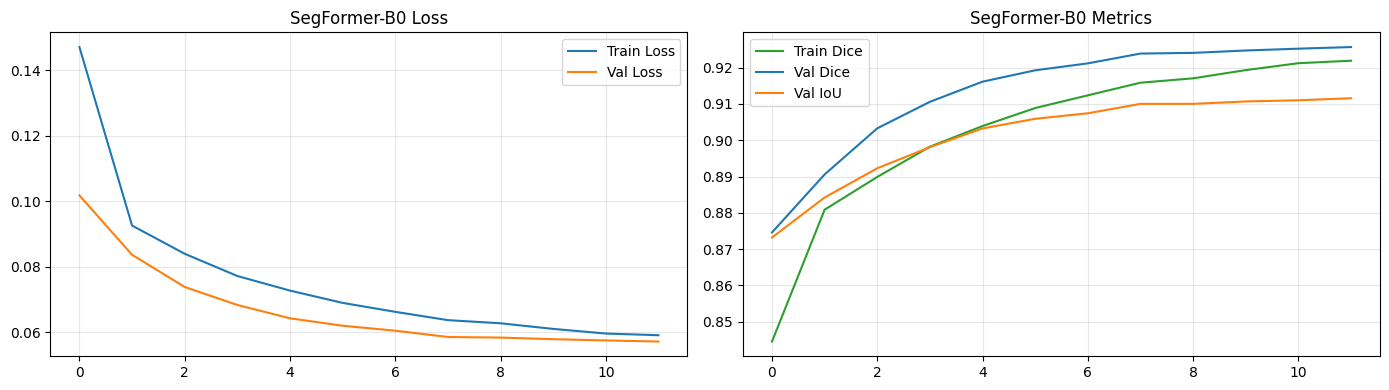

In [8]:
history = fit_segmentation_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=EPOCHS,
    scheduler=scheduler,
    scaler=scaler,
    patience=PATIENCE,
    checkpoint_path='segformer_merged_best.pth',
    model_name='segformer',
    amp_mode=ACTIVE_PROFILE['amp_mode'],
    grad_accumulation_steps=ACTIVE_PROFILE['grad_accumulation_steps'],
    max_grad_norm=ACTIVE_PROFILE['max_grad_norm'],
    use_channels_last=ACTIVE_PROFILE['channels_last'],
    ema_decay=ACTIVE_PROFILE['ema_decay'],
)
fig = plot_training_history(history, title_prefix='SegFormer-B0')
fig.savefig('segformer_merged_history.png', dpi=150)
plt.show()

In [9]:
load_segmentation_checkpoint(model, 'segformer_merged_best.pth', prefer_ema=True)
test_loader = build_segmentation_dataloaders(
    train_df=train_df.head(8),
    val_df=test_df,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=0,
    normalize=NORMALIZE,
)[3]
test_metrics = run_validation_epoch(
    model=model,
    dataloader=test_loader,
    criterion=criterion,
    scaler=scaler,
    amp_mode=ACTIVE_PROFILE['amp_mode'],
    use_channels_last=ACTIVE_PROFILE['channels_last'],
)
test_metrics

/kaggle/input/datasets/rarescocosila/proiect-iava/utils.py:1186: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return autocast(dtype=torch.float16)
/kaggle/input/datasets/rarescocosila/proiect-iava/utils.py:1186: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return autocast(dtype=torch.float16)
/kaggle/input/datasets/rarescocosila/proiect-iava/utils.py:1186: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return autocast(dtype=torch.float16)


{'loss': 0.042101755166684525,
 'dice': 0.9466411049564045,
 'iou': 0.935037338600372}

In [10]:
gpu_benchmark = benchmark_model(model, input_shape=(1, 3, IMG_SIZE, IMG_SIZE), runs=10, warmup=3)
result_row = build_experiment_result_row(
    model_name='segformer_b0_merged',
    history=history,
    benchmark=gpu_benchmark,
    trainable_params=trainable_params,
    optimizer_name=OPTIMIZER_NAME,
    scheduler_name=SCHEDULER_NAME,
    loss_name=LOSS_NAME,
    optimization_profile={**ACTIVE_PROFILE, **opt_info},
)
result_row.update({f'test_{key}': value for key, value in test_metrics.items()})

results = [result_row]
if QUANTIZE_CPU_BENCH:
    quantized_model = quantize_model_for_inference(model)
    quant_benchmark = benchmark_model(quantized_model, input_shape=(1, 3, IMG_SIZE, IMG_SIZE), runs=10, warmup=3, benchmark_device='cpu')
    quant_row = result_row.copy()
    quant_row['model'] = 'segformer_b0_merged_quantized_cpu'
    quant_row.update(quant_benchmark)
    quant_row['opt_quantized_cpu'] = True
    results.append(quant_row)

results_df = pd.DataFrame(results)
results_df.to_csv('segformer_merged_results.csv', index=False)
results_df

,model,epochs_ran,best_epoch,best_val_dice,best_val_iou,best_val_loss,final_train_loss,final_val_loss,optimizer,scheduler,...,opt_grad_accumulation_steps,opt_max_grad_norm,opt_ema_decay,opt_persistent_workers,opt_prefetch_factor,opt_gradient_checkpointing_modules,test_loss,test_dice,test_iou,opt_quantized_cpu
0,segformer_b0_merged,12,12,0.925644,0.911554,0.057165,0.059096,0.057165,adamw,cosine,...,1,1.0,0.999,True,2,[],0.042102,0.946641,0.935037,NaN
1,segformer_b0_merged_quantized_cpu,12,12,0.925644,0.911554,0.057165,0.059096,0.057165,adamw,cosine,...,1,1.0,0.999,True,2,[],0.042102,0.946641,0.935037,True


239161


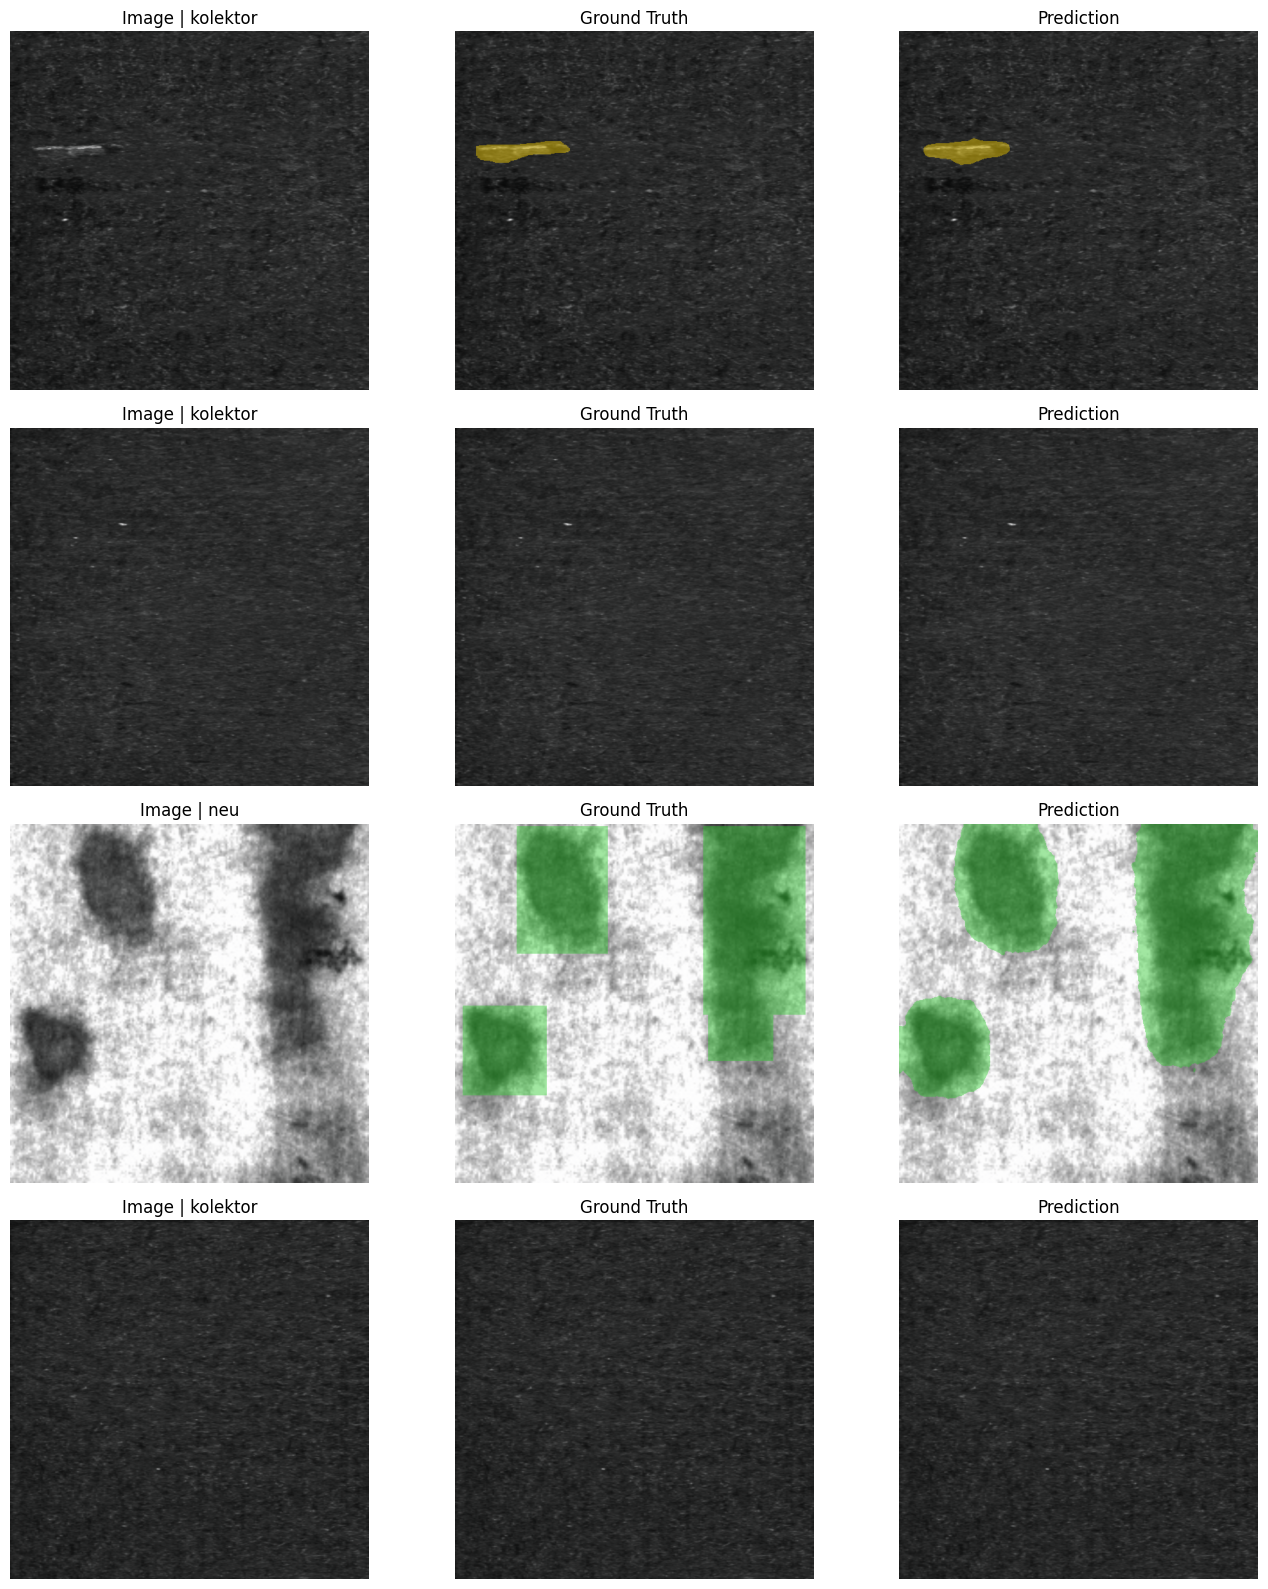

In [36]:
import random

true_random_state = random.SystemRandom().randint(0, 999999)
print(true_random_state)

test_dataset_with_meta = build_segmentation_dataloaders(
    train_df=train_df.head(8),
    val_df=test_df.sample(frac=1, random_state=true_random_state).reset_index(drop=True),
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=0,
    normalize=NORMALIZE,
    return_metadata=True,
)[1]

examples = collect_prediction_examples(model, test_dataset_with_meta, num_samples=4, normalize=NORMALIZE)

fig = visualize_prediction_examples(examples, max_examples=4)
fig.savefig('segformer_test_predictions.png', dpi=150)
plt.show()